In [283]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge , LassoCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV , KFold

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [284]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")

train_ID = df_train['Id']
test_ID = df_test['Id']

df_train.drop("Id", axis = 1, inplace = True)
df_test.drop("Id", axis = 1, inplace = True)


datasets = {
    'Train Dataset': df_train,
    'Test Dataset': df_test,
}


In [285]:
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: xlabel='SalePrice', ylabel='Count'>

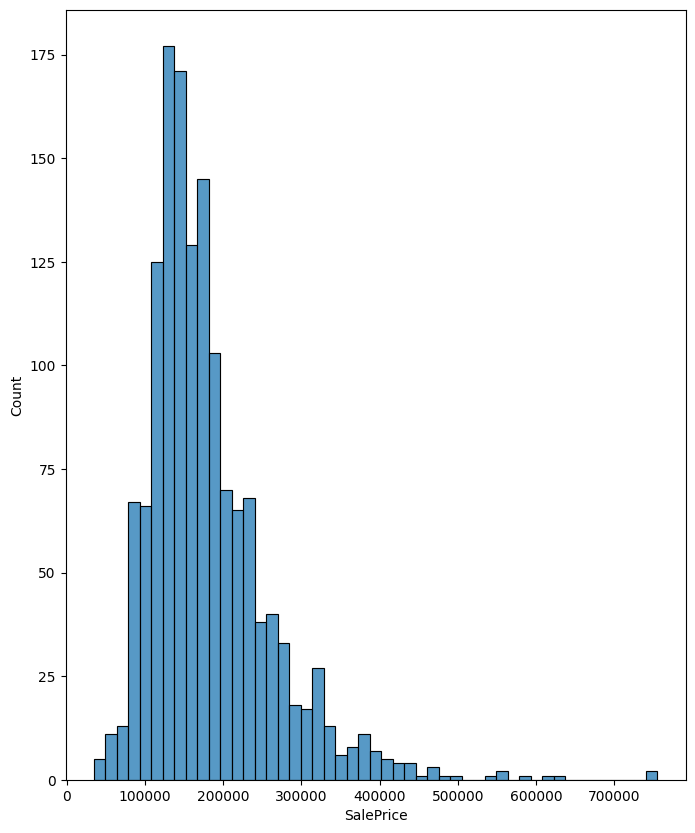

In [286]:
sns.histplot(
    x="SalePrice",
    data=df_train
)

# Standardizing Data

<Axes: xlabel='SalePrice', ylabel='Count'>

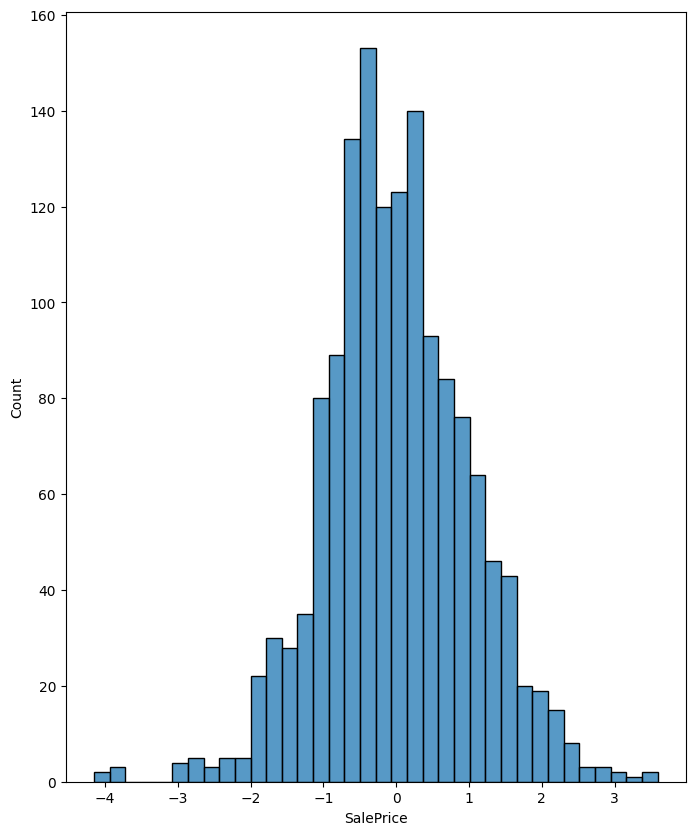

In [287]:
log = PowerTransformer()
log.fit(df_train[['SalePrice']])

df_train['SalePrice'] = log.transform(df_train[["SalePrice"]])

sns.histplot(
    x="SalePrice",
    data=df_train
)

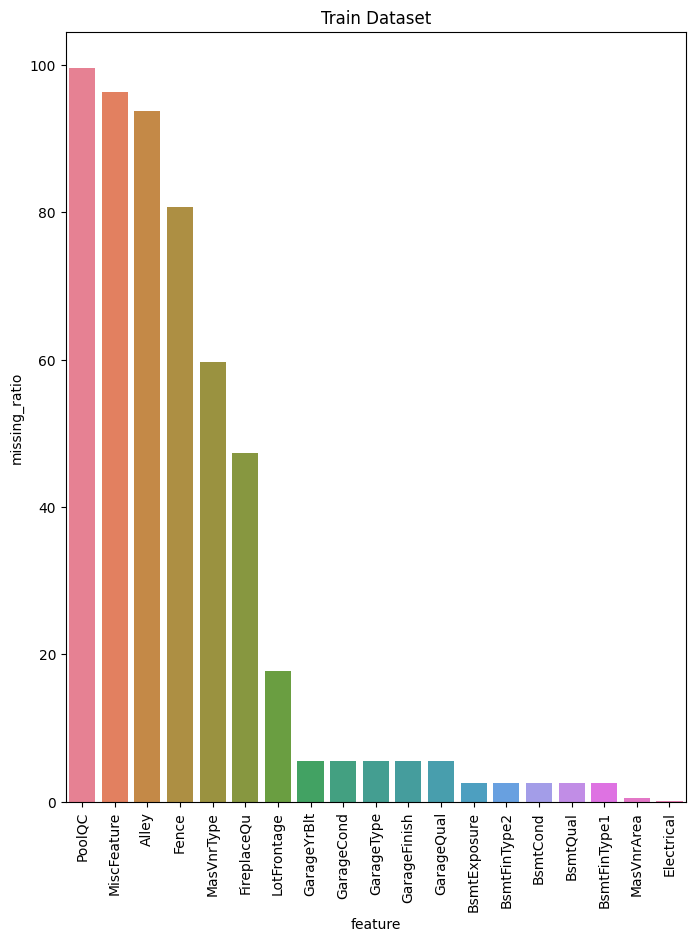

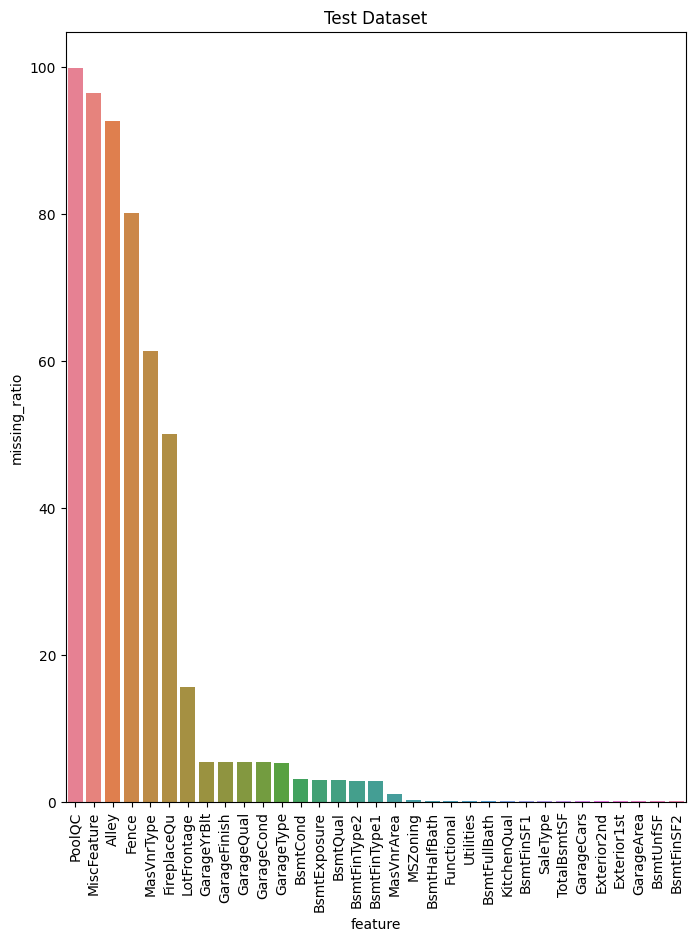

In [288]:
for name, dataset in datasets.items():

    na_values = dataset.isna().sum().reset_index()
    na_values = na_values.rename(columns={'index':'feature', 0:'count'})
    na_values = na_values.sort_values(by='count', ascending=False)

    na_values['missing_ratio'] = na_values['count'] / len(dataset) * 100
    na_values = na_values[na_values['missing_ratio'] != 0]

    sns.barplot(
        x='feature',
        y='missing_ratio',
        data=na_values,
        hue='feature'
    )

    plt.title(name)
    plt.xticks(rotation=90)
    plt.show()

# PoolQC 
- No pool 
- No Qulity

In [289]:
for name , dataset in datasets.items():
    dataset['PoolQC'] = dataset['PoolQC'].fillna('None')

# MiscFeature
- As per the description if there aren't any MiscFeature it is NA : none

In [290]:
for name , dataset in datasets.items():
    dataset['MiscFeature'] = dataset['MiscFeature'].fillna('None')

# Alley 
- No alley
- None

In [291]:
df_test['Alley']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1454    NaN
1455    NaN
1456    NaN
1457    NaN
1458    NaN
Name: Alley, Length: 1459, dtype: str

In [292]:
for name , dataset in datasets.items():
    dataset['Alley'] = dataset['Alley'].fillna('None')
    print(dataset['Alley'].head())

0    None
1    None
2    None
3    None
4    None
Name: Alley, dtype: str
0    None
1    None
2    None
3    None
4    None
Name: Alley, dtype: str


# Fence
- No fence
- None

In [293]:
for name , dataset in datasets.items():
    dataset['Fence'] = dataset['Fence'].fillna('None')

# FireplaceQU
- As description says NA

In [294]:
for name , dataset in datasets.items():
    dataset['FireplaceQu'] = dataset['FireplaceQu'].fillna('None')

# Garage Stuff

In [295]:
for name , dataset in datasets.items():
    for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
        dataset[col] = dataset[col].fillna('None')

In [296]:
for name , dataset in datasets.items():
    for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
        dataset[col] = dataset[col].fillna(0)

# Basement Stuff

In [297]:
for name , dataset in datasets.items():
    for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
        dataset[col] = dataset[col].fillna(0)

In [298]:
for name , dataset in datasets.items():
    for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
        dataset[col] = dataset[col].fillna(0)

# Functional

In [299]:
for name , dataset in datasets.items():
    dataset['Functional'] = dataset['Functional'].fillna('Typ')

# Masonry veneer type

In [300]:
for name , dataset in datasets.items():
    dataset["MasVnrType"] = dataset["MasVnrType"].fillna("None")
    dataset["MasVnrArea"] = dataset["MasVnrArea"].fillna(0)


# Lot Frontage

In [301]:
for name , dataset in datasets.items():
    dataset["LotFrontage"] = dataset.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median()))

# MS Zoning

In [302]:
for name , dataset in datasets.items():
    dataset['MSZoning'] = dataset['MSZoning'].fillna(dataset['MSZoning'].mode()[0])


# functional

In [303]:
for name , dataset in datasets.items():
    dataset['Functional'] = dataset['Functional'].fillna('Typ')


# Electrical

In [304]:
for name , dataset in datasets.items():
    dataset['Electrical'] = dataset['Electrical'].fillna(dataset['Electrical'].mode()[0])

# Utilities

In [305]:
for name , dataset in datasets.items():
    dataset = dataset.drop(['Utilities'], axis=1)

# Kitchen Qual

In [306]:
for name , dataset in datasets.items():
    dataset['KitchenQual'] = dataset['KitchenQual'].fillna(dataset['KitchenQual'].mode()[0])

# Exterior2nd

In [307]:
for name , dataset in datasets.items():
    dataset['Exterior1st'] = dataset['Exterior1st'].fillna(dataset['Exterior1st'].mode()[0])
    dataset['Exterior2nd'] = dataset['Exterior2nd'].fillna(dataset['Exterior2nd'].mode()[0])

# Sale type

In [308]:
for name , dataset in datasets.items():
    dataset['SaleType'] = dataset['SaleType'].fillna(dataset['SaleType'].mode()[0])

Checking any remaining values

In [309]:
df_train.drop(['Utilities'],axis=1)
df_train.columns
df_train.shape


(1460, 80)

In [310]:
print(df_test.shape)
print(df_train.shape)

(1459, 79)
(1460, 80)


In [311]:
cols_unique_to_df1 = df_train.columns.difference(df_test.columns)
print(cols_unique_to_df1)

Index(['SalePrice'], dtype='str')


In [312]:
df_train.dtypes

MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice        float64
Length: 80, dtype: object

In [313]:
for name , dataset in datasets.items():
    dataset['TotalSF'] = dataset['TotalBsmtSF'] + dataset['1stFlrSF'] + dataset['2ndFlrSF']
    print(dataset.columns)

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

**Transforming some numerical variables that are really categorical**

In [314]:
for name , dataset in datasets.items():
    dataset['MSSubClass'] = dataset['MSSubClass'].apply(str)


    #Changing OverallCond into a categorical variable
    dataset['OverallCond'] = dataset['OverallCond'].astype(str)


    #Year and month sold are transformed into categorical features.
    dataset['YrSold'] = dataset['YrSold'].astype(str)
    dataset['MoSold'] = dataset['MoSold'].astype(str)

In [315]:
target = df_train.SalePrice
df_train = df_train.drop('SalePrice',axis=1)


In [317]:
cols = ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'MiscVal',
       'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [337]:
from sklearn.preprocessing import LabelEncoder

train_rows = df_train.shape[0]

combined_df = pd.concat([df_train, df_test], axis=0)

for col in cols:
    lbl = LabelEncoder()
    combined_df[col] = lbl.fit_transform(combined_df[col].astype(str))

df_train = combined_df.iloc[:train_rows].copy()
df_test = combined_df.iloc[train_rows:].copy()

In [338]:
print(df_test.shape)
print(df_train.shape)

(1459, 80)
(1460, 80)


In [343]:
X_train = combined_df.iloc[1459:]

print(X_train)

      MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  LotShape  \
1459           7         3          117     1361       1      1         3   
0              7         2           11      458       1      1         3   
1              7         3           12     1575       1      1         0   
2             12         3           96     1516       1      1         0   
3             12         3            9     1499       1      1         0   
...          ...       ...          ...      ...     ...    ...       ...   
1454           4         4           78     1923       1      1         3   
1455           4         4           78     1912       1      1         3   
1456           7         3           35     1946       1      1         3   
1457           2         3          127      661       1      1         3   
1458          12         3           96     1086       1      1         3   

      LandContour  Utilities  LotConfig  ...  PoolArea  PoolQC  Fence  \
14

In [344]:
X_train_clean = X_train
y_clean = target

In [345]:
def rmse_cv(model):
    rmse= np.sqrt(-cross_val_score(model, X_train, target, scoring="neg_mean_squared_error", cv = 5))
    return(rmse)

Text(0, 0.5, 'rmse')

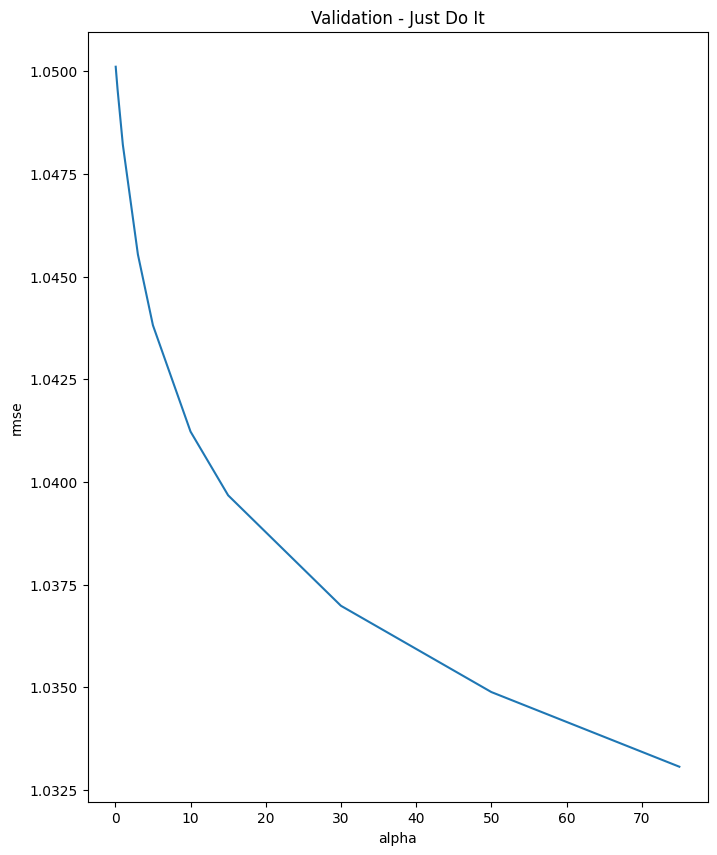

In [346]:
model_ridge = Ridge()
alphas = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75]
model_ridge = Ridge()
alphas = [0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75]
cv_ridge = [rmse_cv(Ridge(alpha = alpha)).mean() 
            for alpha in alphas]
cv_ridge = pd.Series(cv_ridge, index = alphas)
cv_ridge.plot(title = "Validation - Just Do It")
plt.xlabel("alpha")
plt.ylabel("rmse") 

In [347]:
cv_ridge.min()

np.float64(1.0330636266156639)

In [350]:
model_lasso = LassoCV(alphas = [1, 0.1, 0.001, 0.0005]).fit(X_train_clean, target)
rmse_cv(model_lasso).mean()

np.float64(1.0028421238265124)

In [351]:
coef = pd.Series(model_lasso.coef_, index = X_train.columns)

print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 13 variables and eliminated the other 67 variables


In [356]:
imp_coef = pd.concat([coef.sort_values().head(10),
                     coef.sort_values().tail(10)])

Text(0.5, 1.0, 'Coefficients in the Lasso Model')

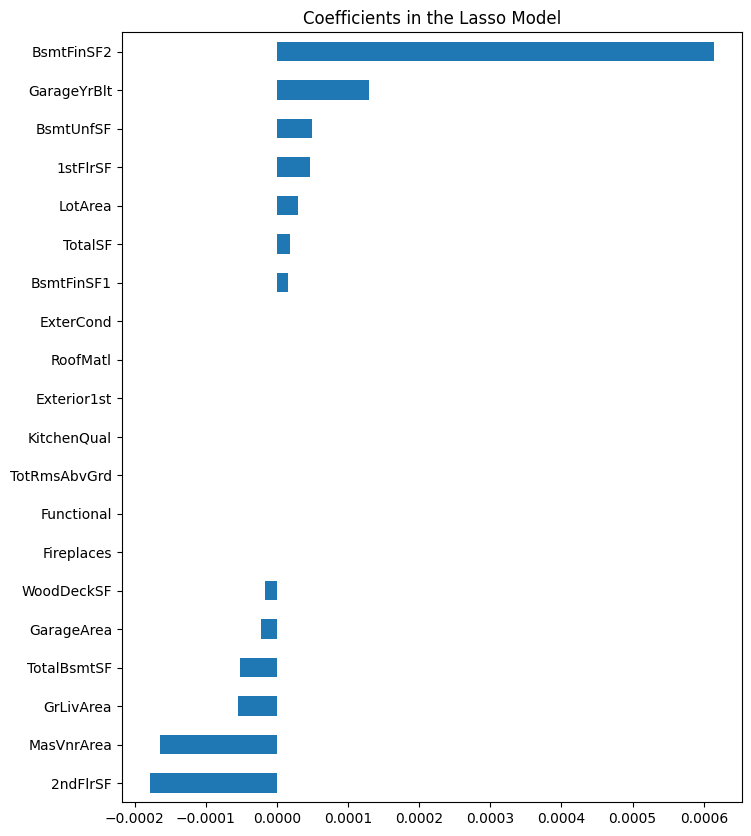

In [357]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Coefficients in the Lasso Model")

<Axes: >

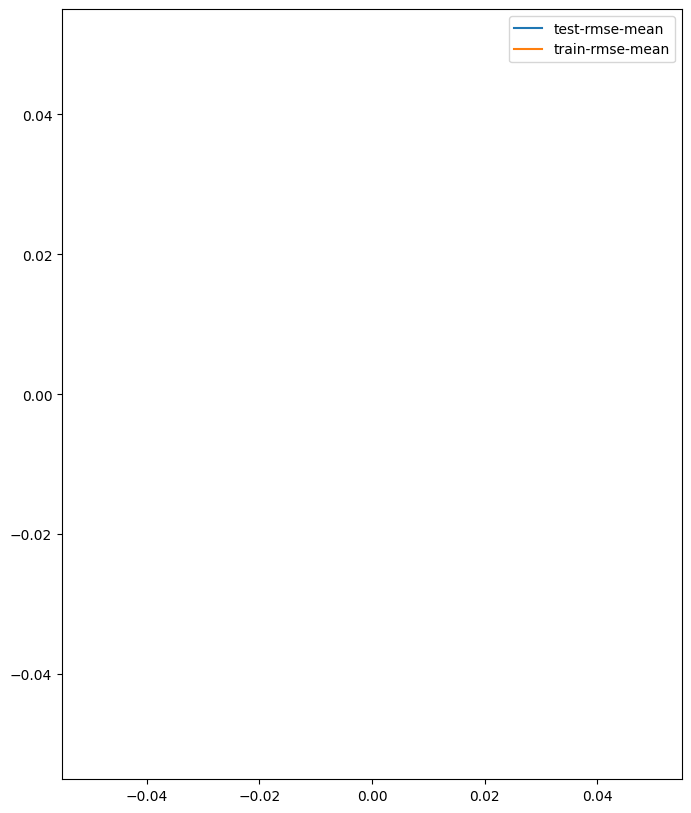

In [358]:
dtrain = xgb.DMatrix(X_train_clean, label = target)

dtest = xgb.DMatrix(df_test)

params = {"max_depth":2, "eta":0.1}
model = xgb.cv(params, dtrain,  num_boost_round=500, early_stopping_rounds=100)

model.loc[30:,["test-rmse-mean", "train-rmse-mean"]].plot()

In [361]:
model_xgb = xgb.XGBRegressor(n_estimators=360, max_depth=2, learning_rate=0.1) #the params were tuned using xgb.cv
model_xgb.fit(X_train_clean, target)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [364]:
xgb_preds = np.expm1(model_xgb.predict(df_test))
lasso_preds = np.expm1(model_lasso.predict(df_test))

In [ ]:
preds = 0.7*lasso_preds + 0.3*xgb_preds
solution = pd.DataFrame({"id":test_ID, "SalePrice":preds})
solution.to_csv("ridge_sol.csv", index = False)

: 